In [1]:
pip install numpy matplotlib tensorflow scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
data = pd.read_excel('predict_energy_consumption.xlsx')
data.head()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
0,24.363503,31.107976,5.234114,705.432695,307.398145
1,38.767858,52.514057,4.939576,817.013258,412.444548
2,33.299849,72.376750,18.125092,325.421109,392.072418
3,29.966462,63.933493,4.990924,662.386690,119.254957
4,18.900466,68.393669,5.438995,614.571385,117.162261


In [5]:
data.tail()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
995,17.289552,59.417309,17.305915,497.896331,453.828793
996,37.932839,77.396877,3.145464,400.961061,103.721455
997,18.420466,24.137481,6.195757,455.115084,197.529277
998,38.755934,23.423283,5.800911,576.946528,417.085421
999,26.150144,36.931224,17.428281,245.230623,318.790570


In [6]:
data.shape

(1000, 5)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         1000 non-null   float64
 1   humidity            1000 non-null   float64
 2   wind_speed          1000 non-null   float64
 3   solar_irradiance    1000 non-null   float64
 4   energy_consumption  1000 non-null   float64
dtypes: float64(5)
memory usage: 39.2 KB


In [8]:
data.describe(include='all')

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,27.256414,50.421038,10.048115,541.337543,272.347395
std,7.303434,17.531394,5.813484,257.840410,129.064474
min,15.115801,20.193096,0.000233,100.588052,50.013823
25%,20.899332,34.464456,5.227020,317.710693,160.238303
50%,27.420184,51.124034,10.012278,535.851355,272.569144
75%,33.607990,65.627903,15.182071,763.786729,382.997053
max,39.992942,79.964824,19.956417,999.601933,498.987225


In [9]:
data.columns

Index(['temperature', 'humidity', 'wind_speed', 'solar_irradiance',
       'energy_consumption'],
      dtype='object')

In [10]:
data.isnull().sum().sum()

0

In [11]:
X = data[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']].values
y = data['energy_consumption'].values

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
import warnings
warnings. filterwarnings('ignore')

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

In [15]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [16]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 90045.1484 - mae: 270.4552 - val_loss: 83471.8906 - val_mae: 258.5755
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 92767.3203 - mae: 275.2081 - val_loss: 82837.4844 - val_mae: 257.3396
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 89343.7344 - mae: 267.8989 - val_loss: 81834.6719 - val_mae: 255.3779
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 85569.5312 - mae: 263.7661 - val_loss: 80273.4844 - val_mae: 252.2893
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 87633.4688 - mae: 266.6140 - val_loss: 77990.7344 - val_mae: 247.7013
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 80321.8359 - mae: 251.6623 - val_loss: 74833.2812 - val_mae: 241.2052
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 79364.2812 - mae: 251.1616 - val_loss: 70585.2891 - val_mae: 232.1596
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 74518.7422 - mae: 240.6220 - val_loss: 65255

In [17]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)
print(f'Test Mean Absolute Error: {test_mae:.2f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 18241.0723 - mae: 116.2547 
Test Mean Absolute Error: 116.46


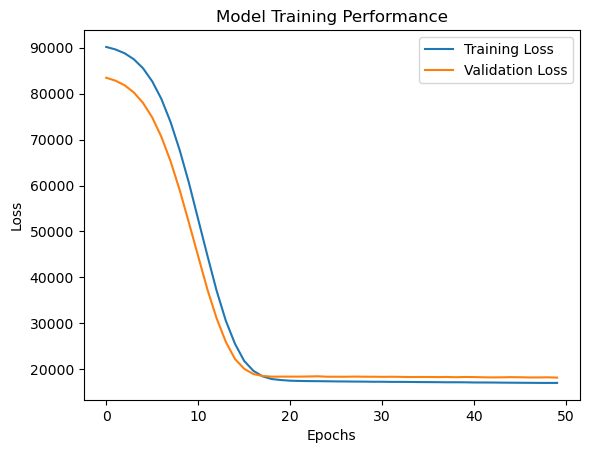

In [18]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training Performance')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [19]:
predictions = model.predict(X_test)
predictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[281.24646],
       [244.7925 ],
       [256.97772],
       [205.32965],
       [343.74908],
       [307.54214],
       [309.94803],
       [280.4125 ],
       [285.79535],
       [276.29605],
       [236.84677],
       [261.81155],
       [282.95996],
       [227.69092],
       [292.29993],
       [310.12653],
       [263.53085],
       [305.54535],
       [296.4278 ],
       [248.75777],
       [277.60974],
       [284.03104],
       [282.175  ],
       [273.81696],
       [246.19266],
       [242.23517],
       [259.70016],
       [314.3587 ],
       [313.7561 ],
       [259.77734],
       [231.23593],
       [306.2409 ],
       [299.19318],
       [273.78635],
       [310.91678],
       [292.45013],
       [210.55959],
       [255.20111],
       [293.17218],
       [241.35992],
       [244.66699],
       [252.1518 ],
       [246.86218],
       [262.1741 ],
       [265.22644],
       [253.41553],
       [267.24847],
       [249.57741],
       [290.6962 ],
       [289.59103],


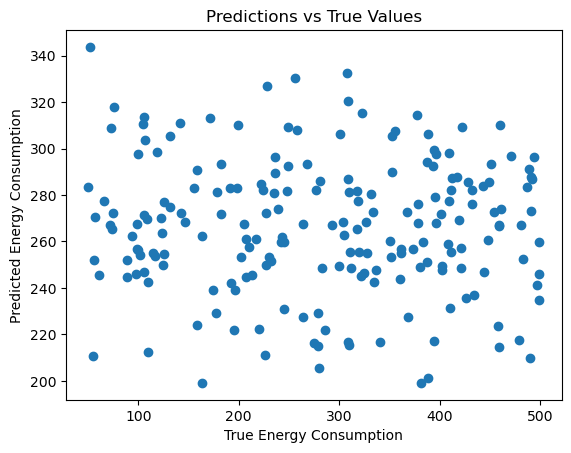

In [20]:
plt.scatter(y_test, predictions)
plt.xlabel('True Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Predictions vs True Values')
plt.show()